In [1]:
import os
import pandas as pd
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
import scienceplots
plt.style.use(['science', 'no-latex'])

# Allow more columns to be displayed
pd.set_option("display.max_columns", None)

import logging
logging.basicConfig(level=logging.WARNING)


IMAGES_PATH = "/Users/klemenkubelj/Documents/school/graduate/masters/code/cvar-masters-thesis-2025/figures"

In [6]:
from utils.flood_request_utils import (
    get_damage_fraction,
    plot_damage_function_full_range,
    residential_damage_fractions,
    commercial_damage_function,
    industrial_damage_function,
    agriculture_damage_function,

    get_wri_and_si_hazard_data,
    plot_wri_and_si_hazard_data,
    get_damage_fraction,
)

In [3]:
%load_ext autoreload
%autoreload 2

# Depth-Damage Function

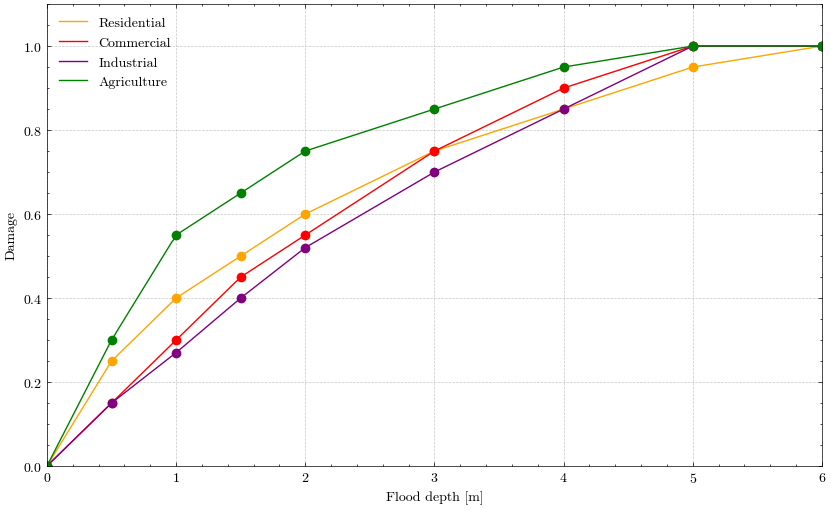

In [5]:
plot_damage_function_full_range("residential", color="orange", label="Residential")
plot_damage_function_full_range("commercial", color="red", label="Commercial")
plot_damage_function_full_range("industrial", color="purple", label="Industrial")
plot_damage_function_full_range("agriculture", color="green", label="Agriculture")
# plt.grid()
# plt.title("Flood Depth-Damage Function (Europe)")

plt.xlim(0, 6)
plt.ylim(0, 1.1)
plt.legend()

# Make wider
plt.gcf().set_size_inches(10, 6)


# EAD

In [7]:
litija_1 = {
    "lng": 14.836790,
    "lat": 46.060307
}
litija_2 = {
    "lng": 14.821837,
    "lat": 46.056977
}

In [8]:
data, request = get_wri_and_si_hazard_data(litija_2)
fig = plot_wri_and_si_hazard_data(data, request)#, x_axis="AEP")
fig.show()

Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
index_values:  [2.0, 5.0, 10.0, 25.0, 50.0, 100.0, 250.0, 500.0, 1000.0]
intensities:  [0.02401801198720932, 0.10212962329387665, 0.1537131667137146, 0.21867892146110535, 0.26687431

In [9]:
fig = plot_wri_and_si_hazard_data(data, request, x_axis="AEP")
fig.show()

index_values:  [0.5, 0.2, 0.1, 0.04, 0.02, 0.01, 0.004, 0.002, 0.001]
intensities:  [0.02401801198720932, 0.10212962329387665, 0.1537131667137146, 0.21867892146110535, 0.2668743133544922, 0.3147137761116028, 0.37761956453323364, 0.4250403046607971, 0.4723888039588928]
index_values:  [0.1, 0.01, 0.002]
intensities:  [0.0, 0.0, 1.5]
index_values:  [0.01]
intensities:  [0.0]


In [10]:
return_periods = data["items"][0]["intensity_curve_set"][0]["index_values"]
exceeded_probabilities = [1 / rp for rp in return_periods]
depths = data["items"][0]["intensity_curve_set"][0]["intensities"]
damage_fractions = [get_damage_fraction(depth) for depth in depths]

value = 100000 # 100k EUR
damage_total = [value * df for df in damage_fractions]


print("return_periods: ", return_periods)
print("exceeded_probabilities: ", exceeded_probabilities)

print("depths: ", depths)
print("damage_fractions: ", damage_fractions)
print("damage_total: ", damage_total)

Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
Property type not provided, using residential as default!!!!!!
return_periods:  [2.0, 5.0, 10.0, 25.0, 50.0, 100.0, 250.0, 500.0, 1000.0]
exceeded_probabilities:  [0.5, 0.2, 0.1, 0.04, 0.02, 0.01, 0.004, 0.002, 0.001]
depths:  [0.02401801198720932, 0.10212962329387665, 0.1537131667137146, 0.21867892146110535, 0.2668743133544922, 0.3147137761116028, 0.37761956453323364, 0.4250403046607971, 0.4723888039588928]
damage_fractions:  [0.01200900599360466, 0.051064811646938324, 0.0768565833568573, 0

In [11]:
def bplot(x, y, xlabel, ylabel, logx: bool = False, color="c"):
    plt.plot(x, y, "o", color=color)
    plt.plot(x, y, color=color)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if logx:
        plt.xscale("log")

    # Add grid lines for both x and y axes
    plt.grid(True, axis="y", linestyle="--", alpha=0.5)
    plt.grid(True, axis="x", which="both",  linestyle="--", alpha=0.5)
    plt.tight_layout()

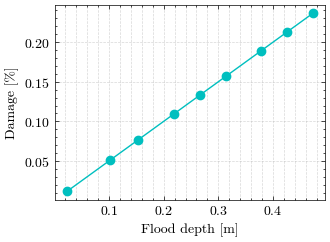

In [12]:
bplot(depths, damage_fractions, "Flood depth [m]", "Damage [%]")

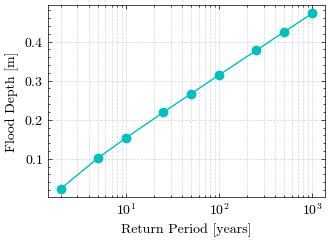

In [13]:
bplot(return_periods, depths, "Return Period [years]", "Flood Depth [m]", logx=True)

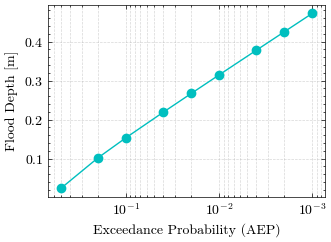

In [14]:
bplot(exceeded_probabilities, depths, "Exceedance Probability (AEP)", "Flood Depth [m]", logx=True)
plt.gca().invert_xaxis()

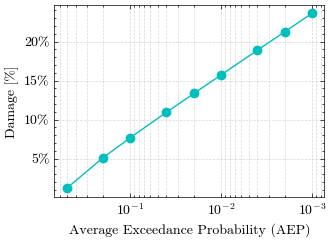

In [21]:
bplot(exceeded_probabilities, damage_fractions, "Average Exceedance Probability (AEP)", "Damage [%]", logx=True)
# Set y to % (whole number) instead of decimal
plt.gca().yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.gca().invert_xaxis()

/var/folders/ly/jtbv8d056fx1pnpygvdlzn0r0000gn/T/ipykernel_22132/1486588245.py:13: UserWarning:

Glyph 8364 (\N{EURO SIGN}) missing from font(s) cmr10.



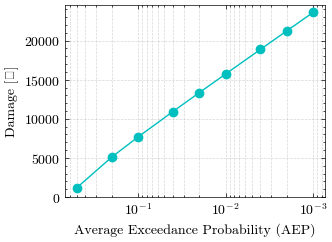

In [22]:
bplot(exceeded_probabilities, damage_total, "Average Exceedance Probability (AEP)", "Damage [€]", logx=True)
plt.ylim(0, max(damage_total)+1000)
plt.gca().invert_xaxis()

/var/folders/ly/jtbv8d056fx1pnpygvdlzn0r0000gn/T/ipykernel_22132/1486588245.py:13: UserWarning:

Glyph 8364 (\N{EURO SIGN}) missing from font(s) cmr10.



Text(0.7, 0.1, 'EAD: 2699 €')

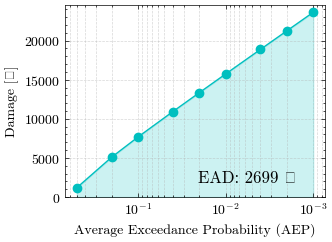

In [23]:
bplot(exceeded_probabilities, damage_total, "Average Exceedance Probability (AEP)", "Damage [€]", logx=True)
plt.ylim(0, max(damage_total)+1000)
plt.gca().invert_xaxis()

# Calculate and display the area under the curve
area_under_curve = abs(np.trapz(damage_total, x=exceeded_probabilities))
plt.fill_between(exceeded_probabilities, damage_total, alpha=0.2, color="c")
plt.text(0.7, 0.1, f"EAD: {area_under_curve:.0f} €", transform=plt.gca().transAxes, fontsize=12, verticalalignment='center', horizontalalignment='center')

/var/folders/ly/jtbv8d056fx1pnpygvdlzn0r0000gn/T/ipykernel_22132/1486588245.py:13: UserWarning:

Glyph 8364 (\N{EURO SIGN}) missing from font(s) cmr10.



Text(0.7, 0.1, 'EAD: 2723.30 €')

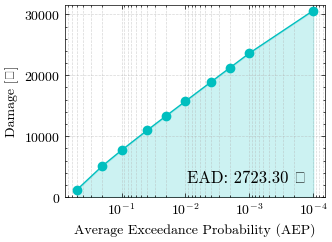

In [24]:
x = exceeded_probabilities + [10**-4,]
y = damage_total + [30619]
bplot(x, y, "Average Exceedance Probability (AEP)", "Damage [€]", logx=True)
plt.ylim(0, max(y)+1000)
plt.gca().invert_xaxis()

# Calculate and display the area under the curve
area_under_curve = abs(np.trapz(y, x=x))
plt.fill_between(x, y, alpha=0.2, color="c")
plt.text(0.7, 0.1, f"EAD: {area_under_curve:.2f} €", transform=plt.gca().transAxes, fontsize=12, verticalalignment='center', horizontalalignment='center')